### Forest disturbance detection with Multi-Kernel 1D U-Net
This notebook trains a 1D U-Net with multi-kernel convolutions to detect forest disturbance events in Landsat time series data.
Small Unet, multikernel conv, focal loss, temporal attention.
Window size is 5, can be used with 3 and 7, test different feature sets (bands, indices).
Split: stratified split by uniqueid to keep train/val/test non-overlapping spatially (good practice) and so each subset has some disturbances
20.10.2025

In [1]:
# Forest Disturbance Detection with Multi-Kernel 1D U-Net
#This notebook trains a 1D U-Net with multi-kernel convolutions to detect forest disturbance events in Landsat time series data.

## 1. Setup & Configuration
## 2. Data Loading 

## 3 Data preprocessing
# Includes target postion, splits by unique_id and save for futther tests, etc:
# Logic is:
# train_loader → training, val_loader → validation (used in train_model + threshold selection), test_loader → independent final metrics
# Thus: Data split by unique location ID into 70% training, 10% validation, and 20% test sets, stratified by the presence of 
# disturbance events. The validation set was used for model selection, hyperparameter tuning, and decision threshold calibration.
# Final performance metrics were computed on the independent test set (20%), which was not used during training or tuning.

## 4. Model: 1D U-Net (Multi-Kernel)
## 5. Training
## 6. Evaluation

### 1. Setup & Configuration

In [2]:
import pandas as pd
pd.set_option('display.max_columns', None)
import matplotlib
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np
from sklearn.model_selection import train_test_split
import random
pd.set_option('display.float_format', '{:.2f}'.format)
np.set_printoptions(suppress=True)
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.utils.data import WeightedRandomSampler
import matplotlib.pyplot as plt
import seaborn as sns

import os
print(os.getcwd())

/home/eoem/Desktop/ai4forest/Code_jorunn_20102025/Code


In [3]:
import torch
import numpy as np
import random
import os

def set_seed(seed=1):
    """
    Set seeds for reproducibility.
    
    Args:
        seed (int): Seed value to use. Default is 42.
    """
    # Set Python seed
    random.seed(seed)
    
    # Set NumPy seed
    np.random.seed(seed)
    
    # Set PyTorch seed
    torch.manual_seed(seed)
    
    # Set CUDA seed if available
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  # for multi-GPU
        
        # Additional CUDA settings for reproducibility
        torch.backends.cudnn.deterministic = True
        
    # Set environment variable for additional reproducibility
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    print(f"Random seed set to {seed}")

# Usage:
set_seed(42)  # or any other number you prefer

Random seed set to 42


### 2. Data Loading

In [4]:
df = pd.read_csv('/home/eoem/Desktop/ai4forest/reference_data/0_calibration/new_dc/forest_dataset_timesync_alltiles_landsatbands_indices3_classes_ed5_calibration.csv',index_col=0, sep=';')
print(df.head())

# create disturbance labels
df['class'] = df['class_level1'].apply(lambda x: 1 if x == 'disturbance' else 0)
print(df.head(10))

import seaborn as sns
import matplotlib.pyplot as plt

# Plot distributions for each feature
features = ['GRN', 'RED', 'NIR', 'NBR', 'NDVI', 'TCB', 'TCG', 'TCW', 'SW1', 'SW2','DIn']
'''for feature in features:
    plt.figure(figsize=(3, 3))
    sns.kdeplot(df[df['new_class2_v5'] == 0][feature], label='Undisturbed', fill=True, color='blue')
    sns.kdeplot(df[df['new_class2_v5'] == 1][feature], label='Disturbed', fill=True, color='red')
    plt.title(f"{feature} Distribution by Class")
    plt.legend()
    plt.show()
'''

## filter doubtful samples
df = df[~((df['class_level1'] == 'treed') & (df['NBR'] < 0.5))]
df = df[~((df['class_level1'] == 'treed') & (df['NDVI'] < 0.5))]
df = df[~((df['class_level1'] == 'non-treed') & (df['NBR'] < 0.5))]
df = df[~((df['class_level1'] == 'non-treed') & (df['NDVI'] < 0.5))]
df = df[~((['class_level1'] == 'disturbance') & (df['NBR'] > 0.5))]
df = df[~((['class_level1'] == 'disturbance') & (df['NDVI'] > 0.5))]

# Count the number of samples per class
class_counts = df['class_level1'].value_counts()
print(class_counts)

     country  plotid  year class_level1 class_level2  new_class2_v5  uniqueid  \
fid                                                                             
0    albania       1  1985        treed        treed              0  albania1   
1    albania       1  1986        treed        treed              0  albania1   
2    albania       1  1987        treed        treed              0  albania1   
3    albania       1  1988        treed        treed              0  albania1   
4    albania       1  1989        treed        treed              0  albania1   

     numerical_id        x           y      Tile_ID     merged_id    BLU  \
fid                                                                        
0               1 20660.18 -1493987.48  X0036_Y0032  1985albania1   5.00   
1               1 20660.18 -1493987.48  X0036_Y0032  1986albania1 293.00   
2               1 20660.18 -1493987.48  X0036_Y0032  1987albania1 161.00   
3               1 20660.18 -1493987.48  X0036_Y0032 

First numerical_id with class=1 is: 1


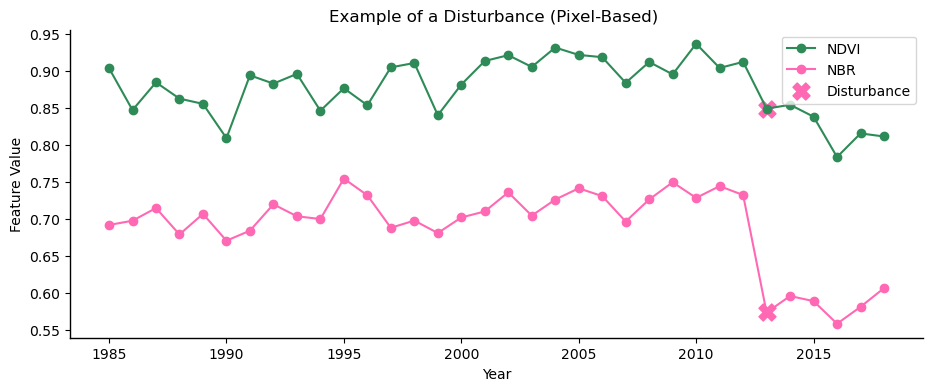

In [5]:
## Example
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

features = ['NDVI', 'NBR']

# Find first row where class == 1
first_idx = np.where(df['class'] == 1)[0][0]
first_num_id = df.loc[first_idx, 'numerical_id']
print(f"First numerical_id with class=1 is: {first_num_id}")

df_num_id = df[df['numerical_id'] == first_num_id]
#sns.set_theme(rc={'figure.figsize': (11, 4)})

# Set the style for clean white background
plt.style.use('default')  # Reset to default style
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 1
plt.rcParams['grid.alpha'] = 0  # Remove grid
plt.figure(figsize=(11, 4))
colors = ['seagreen', 'hotpink']

# Use actual years instead of index
years = df_num_id['year'].values  # Get the actual years

for i, feature in enumerate(features):
    plt.plot(years, df_num_id[feature], marker='o', linestyle='-', label=feature, color = colors[i])

# Find disturbance points and get their years
disturbance_rows = df_num_id.index[df_num_id['class'] == 1]
disturbance_years = df_num_id.loc[disturbance_rows, 'year'].values

for feature in features:
    plt.scatter(disturbance_years,  # Use years instead of row indices
                df_num_id.loc[disturbance_rows, feature],
                color='hotpink', s=150, marker='X',
                label='Disturbance' if feature == features[0] else "")

plt.xlabel('Year')  # Changed from 'Index or Time'
plt.ylabel('Feature Value')
plt.title(f'Example of a Disturbance (Pixel-Based) ')
plt.legend()
sns.despine()
plt.show()

In [26]:
import torch
from torch.optim import Adam
from torch.utils.tensorboard import SummaryWriter
from sklearn.model_selection import train_test_split

# Check CUDA availability
print("CUDA Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Current Device:", torch.cuda.current_device())
    print("Device Name:", torch.cuda.get_device_name(torch.cuda.current_device()))
    torch.cuda.empty_cache()

# Check CUDA availability
if not torch.cuda.is_available():
    print("CUDA is unavailable. Using CPU.")
    device = torch.device("cpu")
else:
    print("CUDA is available!")
    device = torch.device("cuda:0")
    torch.cuda.empty_cache()

# Test a small tensor on the GPU
try:
    x = torch.rand(3, 3).to(device)
    print("GPU Test Passed")
except RuntimeError as e:
    print(f"GPU Test Failed: {e}")

# Print GPU memory info
if torch.cuda.is_available():
    gpu_props = torch.cuda.get_device_properties(0)
    print(f"Total GPU Memory: {gpu_props.total_memory / (1024**3):.2f} GB")
    print(f"Allocated Memory: {torch.cuda.memory_allocated() / (1024**3):.2f} GB")
    print(f"Cached Memory: {torch.cuda.memory_reserved() / (1024**3):.2f} GB")

CUDA Available: True
Current Device: 0
Device Name: NVIDIA RTX A4500
CUDA is available!
GPU Test Passed
Total GPU Memory: 19.71 GB
Allocated Memory: 0.02 GB
Cached Memory: 0.02 GB


### 3. Prepare data, splits, mask traget position

In [6]:
def make_target_mask(m: torch.Tensor, mode: str = "last") -> torch.Tensor:
    """
    Build a 1-hot mask over time per sample using the valid length inferred from m (1=valid, 0=pad).
    Supported modes:
      - "center": floor(center) within the valid part
      - "last": last valid step
      - "second_last": second-to-last valid step (clamped to 0 if length==1)
      - "idx:<int>": fixed index; negatives mean from the end (e.g., idx:-1 == last)
    m: (B, T)
    """
    B, T = m.shape
    lens = m.sum(dim=1).long().clamp(min=1)  # valid lengths per sample

    if mode == "center":
        idx = lens // 2
    elif mode == "last":
        idx = lens - 1
    elif mode == "second_last":
        idx = (lens - 2).clamp(min=0)
    elif mode.startswith("idx:"):
        k = int(mode.split(":", 1)[1])
        # support negative indexing from the end
        idx = torch.where(torch.tensor(k >= 0, device=m.device), torch.full_like(lens, k), lens + k)
        idx = idx.clamp(min=0, max=lens - 1)
    else:
        raise ValueError("mode must be 'center', 'last', 'second_last', or 'idx:<int>'")

    tm = torch.zeros_like(m)
    tm[torch.arange(B, device=m.device), idx] = 1.0
    return tm
    

'''def make_or_load_uid_splits(df, split_path, seed=42):
    """
    Returns (train_uids, val_uids, test_uids) as np arrays.
    If split_path exists, loads it; else creates stratified 70/20/10 by uniqueid and saves.
    Stratification is by whether a uniqueid contains any positive (new_class2_v5 == 1).
    """
    if os.path.exists(split_path):
        z = np.load(split_path, allow_pickle=True)
        return z["train_uids"], z["val_uids"], z["test_uids"]

    uid_groups = df.groupby("uniqueid")["new_class2_v5"]
    uids = uid_groups.count().index.values
    has_pos = (uid_groups.max().values > 0).astype(int)  # 1 if any positive in that id, else 0

    # 70% train, 30% temp (stratified by has_pos)
    train_u, temp_u = train_test_split(
        uids, test_size=0.30, random_state=seed, stratify=has_pos
    )

    # Map uid -> has_pos for stratified secondary split
    pos_map = {u: p for u, p in zip(uids, has_pos)}
    temp_labels = np.array([pos_map[u] for u in temp_u])

    # From 30% temp: 1/3 val (10% overall), 2/3 test (20% overall)
    #val_u, test_u = train_test_split(
    #    temp_u, test_size=0.66, random_state=seed, stratify=temp_labels
    #)
    val_u, test_u = train_test_split(
    temp_u, test_size=2/3, random_state=seed, stratify=temp_labels
    )

    np.savez(split_path, train_uids=train_u, val_uids=val_u, test_uids=test_u, seed=seed)
    return train_u, val_u, test_u'''

def make_or_load_uid_splits(df, split_path, seed=42):
    """
    Returns (train_uids, val_uids, test_uids) as np arrays.
    If split_path exists, loads it; else creates stratified 70/10/20 by uniqueid and saves.
    Stratification is by whether a uniqueid contains any positive (new_class2_v5 == 1).
    Prints class balance per split for verification.
    """
    import numpy as np
    from sklearn.model_selection import train_test_split
    import os

    if os.path.exists(split_path):
        z = np.load(split_path, allow_pickle=True)
        print(f"[INFO] Loaded existing split file: {split_path}")
        return z["train_uids"], z["val_uids"], z["test_uids"]

    # --- Group by uniqueid to ensure stratification at series level ---
    uid_groups = df.groupby("uniqueid")["new_class2_v5"]
    uids = uid_groups.count().index.values
    has_pos = (uid_groups.max().values > 0).astype(int)  # 1 if any disturbance

    # --- 70% train, 30% temp ---
    train_u, temp_u = train_test_split(
        uids, test_size=0.30, random_state=seed, stratify=has_pos
    )

    # Map uid → has_pos
    pos_map = dict(zip(uids, has_pos))
    temp_labels = np.array([pos_map[u] for u in temp_u])

    # --- Of the 30% temp: 1/3 val (10% overall), 2/3 test (20% overall) ---
    val_u, test_u = train_test_split(
        temp_u, test_size=0.66, random_state=seed, stratify=temp_labels
    )

    # --- Save the split for reproducibility ---
    np.savez(split_path, train_uids=train_u, val_uids=val_u, test_uids=test_u, seed=seed)
    print(f"[INFO] Saved new split file: {split_path}")

    # --- Compute class balance per split ---
    def count_pos_neg(uids_subset):
        sub = df[df["uniqueid"].isin(uids_subset)]
        total = len(sub)
        pos = int(sub["new_class2_v5"].sum())
        neg = total - pos
        return total, pos, neg, pos / max(total, 1)

    tr_total, tr_pos, tr_neg, tr_ratio = count_pos_neg(train_u)
    va_total, va_pos, va_neg, va_ratio = count_pos_neg(val_u)
    te_total, te_pos, te_neg, te_ratio = count_pos_neg(test_u)

    print("\n[Split summary by pixel-level samples]")
    print(f"Train: total={tr_total:,} | pos={tr_pos:,} | neg={tr_neg:,} | pos%={100*tr_ratio:.3f}")
    print(f"Val:   total={va_total:,} | pos={va_pos:,} | neg={va_neg:,} | pos%={100*va_ratio:.3f}")
    print(f"Test:  total={te_total:,} | pos={te_pos:,} | neg={te_neg:,} | pos%={100*te_ratio:.3f}")
    print("-----------------------------------------------------------")

    # Also show how many uniqueids contain any disturbance
    def uid_pos_ratio(uids_subset):
        labels = np.array([pos_map[u] for u in uids_subset])
        return labels.sum(), len(labels) - labels.sum(), labels.mean()

    tr_uid_pos, tr_uid_neg, tr_uid_ratio = uid_pos_ratio(train_u)
    va_uid_pos, va_uid_neg, va_uid_ratio = uid_pos_ratio(val_u)
    te_uid_pos, te_uid_neg, te_uid_ratio = uid_pos_ratio(test_u)

    print("[Split summary by uniqueid]")
    print(f"Train: total={len(train_u):,} | disturbed_uids={tr_uid_pos:,} | pos%={100*tr_uid_ratio:.3f}")
    print(f"Val:   total={len(val_u):,} | disturbed_uids={va_uid_pos:,} | pos%={100*va_uid_ratio:.3f}")
    print(f"Test:  total={len(test_u):,} | disturbed_uids={te_uid_pos:,} | pos%={100*te_uid_ratio:.3f}")
    print("===========================================================")

    return train_u, val_u, test_u

In [7]:
# put this dict near the top of file (once)
FEATURE_SETS = {
    "bands": ["BLU", "GRN", "RED", "NIR", "SW1", "SW2"],                 # 6
    "indices": ["NBR", "NDVI", "TCB", "TCG", "TCW", "DIn"],              # 6
    "bands_indices": ["BLU","GRN","RED","NIR","SW1","SW2","NBR","NDVI","TCB","TCG","TCW","DIn"],  # 12
    "prev8": ["RED", "SW1", "SW2", "NBR", "NDVI", "TCG", "TCW", "DIn"],  # my current 8
}

In [8]:
""" 
Don’t fillna(0.0) (keep real missing),
pad with NaN (not 0),
compute min–max on train valid timesteps only, ignoring NaN and −9999,
after scaling, turn remaining NaN/−9999 into 0, and zero-out padded timesteps with the timestep mask.
"""

def prepare_data(df, window_size=5, max_window=5, batch_size=64, device='cpu',
                 split_path="/home/eoem/Desktop/ai4forest/AI_inference/splits/new_class2_v5_seed42_uids_w5_v5_results.npz",
                 seed=42,
                 features_mode="bands_indices",
                 features=None):
    # --- choose features ---
    if features is None:
        features = FEATURE_SETS[features_mode]
    n_features = len(features)
    
    # --- fixed uniqueid splits (create once, then always load) ---
    train_uids, val_uids, test_uids = make_or_load_uid_splits(df, split_path, seed)
    train_uids_set, val_uids_set, test_uids_set = set(train_uids), set(val_uids), set(test_uids)

    # buckets
    X_tr_list, y_tr_list, m_tr_list = [], [], []
    X_va_list, y_va_list, m_va_list = [], [], []
    X_te_list, y_te_list, m_te_list = [], [], []

    def add_sample(uid, X, y, m):
        if uid in train_uids_set:
            X_tr_list.append(X); y_tr_list.append(y); m_tr_list.append(m)
        elif uid in val_uids_set:
            X_va_list.append(X); y_va_list.append(y); m_va_list.append(m)
        elif uid in test_uids_set:
            X_te_list.append(X); y_te_list.append(y); m_te_list.append(m)

    # --- build windows per uniqueid, routed into the right split ---
    for uid, group in df.groupby('uniqueid'):
        if uid not in train_uids_set and uid not in val_uids_set and uid not in test_uids_set:
            continue
        group = group.sort_values('year')
        if len(group) < window_size:
            continue

        # keep true missing values; DO NOT fill here
        data  = group[features].to_numpy(dtype=float)          # shape [T_uid, F]; may contain NaN or -9999
        label = group['new_class2_v5'].to_numpy(dtype=float)   # shape [T_uid]

        for i in range(len(data) - window_size + 1):
            seq_x = data[i:i+window_size]                      # [W, F]
            seq_y = label[i:i+window_size]                     # [W]
            mask  = np.ones(window_size, dtype=np.float32)     # timestep mask (1=real)

            # pad to max_window with NaN for features, 0 for labels, 0 for mask
            pad_len = max_window - window_size
            if pad_len > 0:
                seq_x = np.pad(seq_x, ((0,pad_len),(0,0)), mode='constant', constant_values=np.nan)
                seq_y = np.pad(seq_y, (0,pad_len),          mode='constant', constant_values=0.0)
                mask  = np.pad(mask,  (0,pad_len),          mode='constant', constant_values=0.0)

            add_sample(uid, seq_x, seq_y, mask)

    # stack per split
    def stack_or_empty(XL, yL, mL):
        if len(XL) == 0:
            return (np.empty((0, max_window, len(features)), dtype=float),
                    np.empty((0, max_window), dtype=float),
                    np.empty((0, max_window), dtype=float))
        return np.stack(XL), np.stack(yL), np.stack(mL)

    X_train, y_train, m_train = stack_or_empty(X_tr_list, y_tr_list, m_tr_list)  # [N, T, F], [N, T], [N, T]
    X_val,   y_val,   m_val   = stack_or_empty(X_va_list, y_va_list, m_va_list)
    X_test,  y_test,  m_test  = stack_or_empty(X_te_list, y_te_list, m_te_list)

    # --- normalization: per-feature min–max using TRAIN valid timesteps only, ignoring NaN and -9999 ---
    if X_train.shape[0] == 0:
        raise RuntimeError("Empty training split after windowing. Check filters/window_size.")

    def to_nan(x):
        x = x.copy()
        x[x == -9999.0] = np.nan
        return x

    X_train_nan = to_nan(X_train)
    X_val_nan   = to_nan(X_val)
    X_test_nan  = to_nan(X_test)

    N_tr, T, F = X_train_nan.shape
    Xt_tr = X_train_nan.reshape(-1, F)           # [N_tr*T, F]
    mt_tr = m_train.reshape(-1).astype(bool)     # [N_tr*T]
    Xt_tr_valid = Xt_tr[mt_tr]                   # only real timesteps (exclude padding)

    feat_min = np.nanmin(Xt_tr_valid, axis=0, keepdims=True)  # [1, F]
    feat_max = np.nanmax(Xt_tr_valid, axis=0, keepdims=True)
    feat_rng = np.clip(feat_max - feat_min, 1e-8, None)

    def norm_per_feature(X_nan, M):
        # scale
        Xn = (X_nan - feat_min.reshape(1,1,F)) / feat_rng.reshape(1,1,F)
        # turn any NaN (from padded steps or -9999) into 0
        Xn = np.where(np.isnan(Xn), 0.0, Xn)
        # zero-out padded timesteps explicitly
        Xn = Xn * M[..., None]
        return np.clip(Xn, 0.0, 1.0)

    X_train = norm_per_feature(X_train_nan, m_train)
    X_val   = norm_per_feature(X_val_nan,   m_val)
    X_test  = norm_per_feature(X_test_nan,  m_test)

    # (Optional) persist stats for inference-time normalization
    np.save("/home/eoem/Desktop/ai4forest/AI_inference/models_unet/min_train_w5_back_bands_indices_v5_results.npy", feat_min)
    np.save("/home/eoem/Desktop/ai4forest/AI_inference/models_unet/max_train_w5_back_bands_indices_v5_results.npy", feat_max)

    # --- tensors in (B, C, T) for Conv1d/U-Net ---
    # Prepare data for PyTorch
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32).permute(0,2,1)  # (B, C, T)
    X_val_tensor   = torch.tensor(X_val,   dtype=torch.float32).permute(0,2,1)
    X_test_tensor  = torch.tensor(X_test,  dtype=torch.float32).permute(0,2,1)

    y_train_tensor = torch.tensor(y_train, dtype=torch.float32)  # (B, T)
    y_val_tensor   = torch.tensor(y_val,   dtype=torch.float32)
    y_test_tensor  = torch.tensor(y_test,  dtype=torch.float32)

    m_train_tensor = torch.tensor(m_train, dtype=torch.float32)  # (B, T) 1=valid timestep, 0=pad
    m_val_tensor   = torch.tensor(m_val,   dtype=torch.float32)
    m_test_tensor  = torch.tensor(m_test,  dtype=torch.float32)

    # datasets/loaders
    train_ds = TensorDataset(X_train_tensor, y_train_tensor, m_train_tensor)
    val_ds   = TensorDataset(X_val_tensor,   y_val_tensor,   m_val_tensor)
    test_ds  = TensorDataset(X_test_tensor,  y_test_tensor,  m_test_tensor)

    from torch.utils.data import DataLoader
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=0, pin_memory=False, persistent_workers=False)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=False, persistent_workers=False)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=False, persistent_workers=False)

    return train_loader, val_loader, test_loader, n_features, features

In [9]:
import os, torch
os.environ["CUDA_VISIBLE_DEVICES"] = "0"  # ensure we see GPU 0 only
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

def safe_to_device(module, device):
    try:
        return module.to(device)
    except RuntimeError as e:
        print("[WARN] CUDA issue, falling back to CPU:", e)
        torch.cuda.empty_cache()
        return module.to("cpu")

## run preprocessing data
train_loader, val_loader, test_loader, nF, used_feats = prepare_data(
    df=df,
    window_size=5,
    max_window=5,
    batch_size=64,
    device=device,
    features_mode="bands_indices"  # or "bands" / "bands_indices"
)

print("Using features:", used_feats)

[INFO] Loaded existing split file: /home/eoem/Desktop/ai4forest/AI_inference/splits/new_class2_v5_seed42_uids_w5_v5_results.npz
Using features: ['BLU', 'GRN', 'RED', 'NIR', 'SW1', 'SW2', 'NBR', 'NDVI', 'TCB', 'TCG', 'TCW', 'DIn']


In [10]:
## to inspect the split, stratified per uniqueid

def print_split_balances(df, train_uids, val_uids, test_uids):
    import numpy as np
    def count_pos_neg(uids_subset):
        sub = df[df["uniqueid"].isin(uids_subset)]
        total = len(sub); pos = int(sub["new_class2_v5"].sum()); neg = total - pos
        return total, pos, neg, pos / max(total, 1)

    tr_total, tr_pos, tr_neg, tr_ratio = count_pos_neg(train_uids)
    va_total, va_pos, va_neg, va_ratio = count_pos_neg(val_uids)
    te_total, te_pos, te_neg, te_ratio = count_pos_neg(test_uids)

    print("\n[Split summary by pixel-level samples]")
    print(f"Train: total={tr_total:,} | pos={tr_pos:,} | neg={tr_neg:,} | pos%={100*tr_ratio:.3f}")
    print(f"Val:   total={va_total:,} | pos={va_pos:,} | neg={va_neg:,} | pos%={100*va_ratio:.3f}")
    print(f"Test:  total={te_total:,} | pos={te_pos:,} | neg={te_neg:,} | pos%={100*te_ratio:.3f}")
    print("-----------------------------------------------------------")

    # uniqueid-level balance
    uid_groups = df.groupby("uniqueid")["new_class2_v5"]
    uids = uid_groups.count().index.values
    has_pos = (uid_groups.max().values > 0).astype(int)
    pos_map = dict(zip(uids, has_pos))

    def uid_pos_ratio(uids_subset):
        labels = np.array([pos_map[u] for u in uids_subset])
        return labels.sum(), len(labels) - labels.sum(), labels.mean()

    tr_uid_pos, _, tr_uid_ratio = uid_pos_ratio(train_uids)
    va_uid_pos, _, va_uid_ratio = uid_pos_ratio(val_uids)
    te_uid_pos, _, te_uid_ratio = uid_pos_ratio(test_uids)

    print("[Split summary by uniqueid]")
    print(f"Train: total={len(train_uids):,} | disturbed_uids={tr_uid_pos:,} | pos%={100*tr_uid_ratio:.3f}")
    print(f"Val:   total={len(val_uids):,} | disturbed_uids={va_uid_pos:,} | pos%={100*va_uid_ratio:.3f}")
    print(f"Test:  total={len(test_uids):,} | disturbed_uids={te_uid_pos:,} | pos%={100*te_uid_ratio:.3f}")
    print("===========================================================")

train_uids, val_uids, test_uids = make_or_load_uid_splits(
    df, "/home/eoem/Desktop/ai4forest/AI_inference/splits/new_class2_v5_seed42_uids_w5_v5_results.npz"
)
print_split_balances(df, train_uids, val_uids, test_uids)

[INFO] Loaded existing split file: /home/eoem/Desktop/ai4forest/AI_inference/splits/new_class2_v5_seed42_uids_w5_v5_results.npz

[Split summary by pixel-level samples]
Train: total=367,609 | pos=1,459 | neg=366,150 | pos%=0.397
Val:   total=53,575 | pos=219 | neg=53,356 | pos%=0.409
Test:  total=103,588 | pos=416 | neg=103,172 | pos%=0.402
-----------------------------------------------------------
[Split summary by uniqueid]
Train: total=11,867 | disturbed_uids=1,357 | pos%=11.435
Val:   total=1,729 | disturbed_uids=198 | pos%=11.452
Test:  total=3,358 | disturbed_uids=384 | pos%=11.435


In [32]:
@torch.no_grad()
def count_supervised_positives(loader, target_mode="last", device="cpu"):
    model_dummy = nn.Identity()  # not used; we just want masks
    pos = 0; tot = 0
    for x, y, m in loader:
        m = m.to(device); y = y.to(device)
        tm = make_target_mask(m, mode=target_mode)  # (B, T)
        tgt = y[tm.bool()]
        pos += int(tgt.sum().item())
        tot += int(tgt.numel())
    return pos, tot, (pos / max(tot,1))
    
TARGET_MODE= "last"
tr_pos, tr_tot, tr_rate = count_supervised_positives(train_loader, target_mode=TARGET_MODE, device=device)
va_pos, va_tot, va_rate = count_supervised_positives(val_loader,   target_mode=TARGET_MODE, device=device)
te_pos, te_tot, te_rate = count_supervised_positives(test_loader,  target_mode=TARGET_MODE, device=device)

print(f"[Supervised index only] Train: pos={tr_pos}/{tr_tot} ({100*tr_rate:.3f}%)")
print(f"[Supervised index only] Val:   pos={va_pos}/{va_tot} ({100*va_rate:.3f}%)")
print(f"[Supervised index only] Test:  pos={te_pos}/{te_tot} ({100*te_rate:.3f}%)")


[Supervised index only] Train: pos=1336/320371 (0.417%)
[Supervised index only] Val:   pos=196/46693 (0.420%)
[Supervised index only] Test:  pos=354/90229 (0.392%)


### 4. Model definition

In [20]:
## i decided to run option 2 below, this option 1 was my model
import torch.nn as nn
''' window size 3 and target position X'''
# Define the multi-kernel conv block first
'''is a multi-scale convolutional block. It applies several 1D convolutions in parallel with different kernel sizes (e.g., 3, 5, 7) 
and concatenates their outputs. It lets the network capture temporal patterns at multiple scales: Sharp changes (e.g., fire in 1 year),
Gradual changes (e.g., slow dieback over several years).'''

class MultiKernelConv1d(nn.Module):
    def __init__(self, in_channels, out_channels, p_drop=0.2):
        super().__init__()
        self.b3 = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(inplace=True),
        )
        self.b5 = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size=5, padding=2),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(inplace=True),
        )
        self.b7 = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size=7, padding=3),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(inplace=True),
        )
        self.dropout = nn.Dropout1d(p_drop)

    def forward(self, x):
        x_cat = torch.cat([self.b3(x), self.b5(x), self.b7(x)], dim=1)  # concat along channel dim
        return self.dropout(x_cat)

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.85, gamma=2.5, reduction='none'):
        super().__init__()
        assert 0.0 <= alpha <= 1.0, "alpha must be in [0,1]"
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        # inputs: logits, same shape as targets (e.g., B x T)
        # targets: {0,1} float tensor
        bce = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt  = torch.exp(-bce)  # prob of the true class
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        loss = alpha_t * (1 - pt) ** self.gamma * bce

        if self.reduction == 'none':
            return loss                 # per-element (B x T)
        elif self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()

class TemporalSelfAttention(nn.Module):
    def __init__(self, embed_dim):
        super().__init__()
        self.query = nn.Linear(embed_dim, embed_dim)
        self.key = nn.Linear(embed_dim, embed_dim)
        self.value = nn.Linear(embed_dim, embed_dim)
        self.scale = embed_dim ** -0.5

    def forward(self, x):
        # x: (batch, channels, time)
        x = x.permute(0, 2, 1)  # -> (batch, time, channels)
        Q = self.query(x)
        K = self.key(x)
        V = self.value(x)

        attn_weights = torch.softmax((Q @ K.transpose(-2, -1)) * self.scale, dim=-1)
        attended = attn_weights @ V

        return attended.permute(0, 2, 1)  # -> (batch, channels, time)
        

class SmallUNet1D(nn.Module):
    """
    2-level 1D U-Net that works for tiny/odd T.
    Uses your MultiKernelConv1d blocks (k=3/5/7 with BN+ReLU+Dropout inside each branch).
    Encoder: 2x (MKConv -> AvgPool(ceil_mode=True))
    Bottleneck: 1x1 Conv -> BN -> ReLU + temporal self-attention
    Decoder: interpolate up -> concat skip -> 1x1 Conv (reduce)  [repeat]
    Head: 1x1 Conv -> logits per timestep
    """
    def __init__(self, in_channels, base=16, p_drop=0.2):
        super().__init__()
        # ---- Encoder (note: MultiKernelConv1d(out_ch=X) returns 3*X channels after concat) ----
        self.enc1 = MultiKernelConv1d(in_channels=in_channels, out_channels=base, p_drop=p_drop)       # -> (B, 3b, T)
        self.pool1 = nn.AvgPool1d(kernel_size=2, ceil_mode=True)                                       # T -> ceil(T/2)

        self.enc2 = MultiKernelConv1d(in_channels=3*base, out_channels=2*base, p_drop=p_drop)          # -> (B, 6b, T/2)
        self.pool2 = nn.AvgPool1d(kernel_size=2, ceil_mode=True)                                       # T/2 -> ceil(T/4)

        # ---- Bottleneck ----
        bottleneck_ch = 4*base
        self.bn_conv = nn.Sequential(
            nn.Conv1d(in_channels=6*base, out_channels=bottleneck_ch, kernel_size=1),
            nn.BatchNorm1d(bottleneck_ch),
            nn.ReLU(inplace=True),
        )
        self.attn = TemporalSelfAttention(embed_dim=bottleneck_ch)

        # ---- Decoder (interpolate + 1x1 conv to reduce channels) ----
        # Up to enc2 feature length
        self.dec2_reduce = nn.Sequential(
            nn.Conv1d(in_channels=bottleneck_ch + 6*base, out_channels=6*base, kernel_size=1),
            nn.BatchNorm1d(6*base),
            nn.ReLU(inplace=True),
        )
        # Up to enc1 feature length
        self.dec1_reduce = nn.Sequential(
            nn.Conv1d(in_channels=6*base + 3*base, out_channels=3*base, kernel_size=1),
            nn.BatchNorm1d(3*base),
            nn.ReLU(inplace=True),
        )

        # ---- Head ----
        self.out_conv = nn.Conv1d(in_channels=3*base, out_channels=1, kernel_size=1)

    def forward(self, x):
        # Encoder
        x1f = self.enc1(x)                 # (B, 3b, T1)
        x1  = self.pool1(x1f)              # (B, 3b, T1p)

        x2f = self.enc2(x1)                # (B, 6b, T2)
        x2  = self.pool2(x2f)              # (B, 6b, T2p)

        # Bottleneck
        xb = self.bn_conv(x2)              # (B, 4b, T2p)
        xb = self.attn(xb)                 # (B, 4b, T2p)

        # Decoder stage 2: up to x2f length
        y = F.interpolate(xb, size=x2f.size(2), mode='linear', align_corners=False)
        y = torch.cat([y, x2f], dim=1)     # (B, 4b+6b, T2)
        y = self.dec2_reduce(y)            # (B, 6b, T2)

        # Decoder stage 1: up to x1f length
        y = F.interpolate(y, size=x1f.size(2), mode='linear', align_corners=False)
        y = torch.cat([y, x1f], dim=1)     # (B, 6b+3b, T1)
        y = self.dec1_reduce(y)            # (B, 3b, T1)

        out = self.out_conv(y).squeeze(1)  # (B, T1)
        return out

In [33]:
### option 2 of the model, taking the temproal dropout from Jorunn to make it robust to gaps
### and also the adapted kenerl in the convoltuions for big or small

class TemporalDropout(nn.Module):
    def __init__(self, dropout_rate=0.2):
        super().__init__()
        self.dropout_rate = dropout_rate
    def forward(self, x):
        if not self.training or self.dropout_rate == 0.0:
            return x
        B, C, T = x.shape
        mask = (torch.rand(B, T, device=x.device) > self.dropout_rate).float().unsqueeze(1)
        return x * mask

# 2) MultiKernelConv1d with selectable norm + kernel set
# norm='bn' for BatchNorm (your current default), norm='ln' to get LayerNorm-like via GroupNorm(1, C), or norm='gn8' for GroupNorm(8).
# kernel_sizes selectable (use (1,3,5) for small T).
class MultiKernelConv1d(nn.Module):
    def __init__(self, in_channels, out_channels, p_drop=0.2,
                 kernel_sizes=(1,3,5), norm='bn'):
        super().__init__()
        self.branches = nn.ModuleList()
        for k in kernel_sizes:
            layers = [nn.Conv1d(in_channels, out_channels, kernel_size=k, padding=k//2)]
            if norm == 'bn':
                layers += [nn.BatchNorm1d(out_channels)]
            elif norm == 'ln':
                layers += [nn.GroupNorm(1, out_channels)]     # LN-like over channels
            elif norm.startswith('gn'):
                g = int(norm[2:]) if norm[2:].isdigit() else 8
                layers += [nn.GroupNorm(g, out_channels)]
            else:
                raise ValueError("norm must be 'bn', 'ln', or 'gnK'")
            layers += [nn.ReLU(inplace=True)]
            self.branches.append(nn.Sequential(*layers))
        self.dropout = nn.Dropout1d(p_drop)

    def forward(self, x):
        y = torch.cat([b(x) for b in self.branches], dim=1)  # (B, len(ks)*out_channels, T)
        return self.dropout(y)

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.85, gamma=2.5, reduction='none'):
        super().__init__()
        assert 0.0 <= alpha <= 1.0, "alpha must be in [0,1]"
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        # inputs: logits, same shape as targets (e.g., B x T)
        # targets: {0,1} float tensor
        bce = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt  = torch.exp(-bce)  # prob of the true class
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        loss = alpha_t * (1 - pt) ** self.gamma * bce

        if self.reduction == 'none':
            return loss                 # per-element (B x T)
        elif self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()

class TemporalSelfAttention(nn.Module):
    def __init__(self, embed_dim):
        super().__init__()
        self.query = nn.Linear(embed_dim, embed_dim)
        self.key = nn.Linear(embed_dim, embed_dim)
        self.value = nn.Linear(embed_dim, embed_dim)
        self.scale = embed_dim ** -0.5

    def forward(self, x):
        # x: (batch, channels, time)
        x = x.permute(0, 2, 1)  # -> (batch, time, channels)
        Q = self.query(x)
        K = self.key(x)
        V = self.value(x)

        attn_weights = torch.softmax((Q @ K.transpose(-2, -1)) * self.scale, dim=-1)
        attended = attn_weights @ V

        return attended.permute(0, 2, 1)  # -> (batch, channels, time)
        
# SmallUNet1D updated
# Adds TemporalDropout at the input.
# Lets you pick norm and kernel set once, then reuses everywhere.
# Still uses interpolate upsampling (good for tiny/odd T).

class SmallUNet1D(nn.Module):
    def __init__(self, in_channels, base=16, p_drop=0.2,
                 norm='ln',                 # ← default to LN-like for small batches
                 kernel_sizes_small=(1,3,5),
                 kernel_sizes_big=(3,5,7),
                 tdrop_rate=0.2):
        super().__init__()
        self.tdrop = TemporalDropout(tdrop_rate)

        # choose kernels once (you can also make this conditional on expected T)
        ks1 = kernel_sizes_small   # for first two levels with small T setups
        ks2 = kernel_sizes_small

        # ---- Encoder ----
        self.enc1 = MultiKernelConv1d(in_channels, base, p_drop=p_drop, kernel_sizes=ks1, norm=norm)   # -> (B, 3*base, T)
        self.pool1 = nn.AvgPool1d(2, ceil_mode=True)

        self.enc2 = MultiKernelConv1d(3*base, 2*base, p_drop=p_drop, kernel_sizes=ks2, norm=norm)      # -> (B, 3*2*base, T/2)
        self.pool2 = nn.AvgPool1d(2, ceil_mode=True)

        # ---- Bottleneck ----
        bottleneck_ch = 4*base
        self.bn_conv = nn.Sequential(
            nn.Conv1d(6*base, bottleneck_ch, 1),
            nn.GroupNorm(1, bottleneck_ch) if norm=='ln' else
            (nn.GroupNorm(8, bottleneck_ch) if norm.startswith('gn') else nn.BatchNorm1d(bottleneck_ch)),
            nn.ReLU(inplace=True),
        )
        self.attn = TemporalSelfAttention(embed_dim=bottleneck_ch)

        # ---- Decoder ----
        self.dec2_reduce = nn.Sequential(
            nn.Conv1d(bottleneck_ch + 6*base, 6*base, 1),
            nn.GroupNorm(1, 6*base) if norm=='ln' else
            (nn.GroupNorm(8, 6*base) if norm.startswith('gn') else nn.BatchNorm1d(6*base)),
            nn.ReLU(inplace=True),
        )
        self.dec1_reduce = nn.Sequential(
            nn.Conv1d(6*base + 3*base, 3*base, 1),
            nn.GroupNorm(1, 3*base) if norm=='ln' else
            (nn.GroupNorm(8, 3*base) if norm.startswith('gn') else nn.BatchNorm1d(3*base)),
            nn.ReLU(inplace=True),
        )

        # ---- Head ----
        self.out_conv = nn.Conv1d(3*base, 1, 1)

    def forward(self, x):
        x = self.tdrop(x)  # temporal dropout at input
        x1f = self.enc1(x);  x1  = self.pool1(x1f)
        x2f = self.enc2(x1); x2  = self.pool2(x2f)

        xb = self.bn_conv(x2)
        xb = self.attn(xb)

        y  = F.interpolate(xb, size=x2f.size(2), mode='linear', align_corners=False)
        y  = self.dec2_reduce(torch.cat([y, x2f], dim=1))

        y  = F.interpolate(y, size=x1f.size(2), mode='linear', align_corners=False)
        y  = self.dec1_reduce(torch.cat([y, x1f], dim=1))

        return self.out_conv(y).squeeze(1)  # (B, T)


### 5. Training the model

In [12]:
'''4. Training and Validation Function'''
def train_model(model, train_loader, val_loader, device, loss_fn, optimizer, num_epochs=30, target_mode="last"):
    for epoch in range(num_epochs):
        model.train()
        train_loss, train_f1 = 0.0, 0.0
        for x, y, m in train_loader:
            x, y, m = x.to(device), y.to(device), m.to(device)
            optimizer.zero_grad()

            y_hat = model(x)                   # (B, T)
            per_elem = loss_fn(y_hat, y)       # (B, T)

            tm = make_target_mask(m, mode=target_mode)  # <<< NEW
            loss = (per_elem * tm).sum() / (tm.sum() + 1e-8)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # (optional but helpful)
            optimizer.step()

            preds = (torch.sigmoid(y_hat) > 0.5).float()
            train_f1 += f1_score(
                y[tm.bool()].cpu(), preds[tm.bool()].cpu(), zero_division=0
            )
            train_loss += loss.item()

        train_loss /= len(train_loader)
        train_f1   /= len(train_loader)

        # --- validation ---
        model.eval()
        val_loss, val_f1 = 0.0, 0.0
        with torch.no_grad():
            for x, y, m in val_loader:
                x, y, m = x.to(device), y.to(device), m.to(device)
                y_hat = model(x)
                per_elem = loss_fn(y_hat, y)
                tm = make_target_mask(m, mode=target_mode)  # <<< NEW
                loss = (per_elem * tm).sum() / (tm.sum() + 1e-8)

                preds = (torch.sigmoid(y_hat) > 0.5).float()
                val_f1 += f1_score(
                    y[tm.bool()].cpu(), preds[tm.bool()].cpu(), zero_division=0
                )
                val_loss += loss.item()

        val_loss /= len(val_loader)
        val_f1   /= len(val_loader)
        print(f"Epoch {epoch+1:02d} | TrainLoss {train_loss:.4f} | TrainF1 {train_f1:.4f} | ValLoss {val_loss:.4f} | ValF1 {val_f1:.4f}")


''' run training'''
# model = safe_to_device(AlbasUNet(in_channels=nF), device)   # ← old
### OPTION 1
# model = safe_to_device(SmallUNet1D(in_channels=nF, base=16, p_drop=0.2), device)  # ← new
### OPTION 2
# pick norm based on batch size:
#   small batches (<16): norm='ln' (via GN(1,C)) or norm='gn8'
#   larger batches: norm='bn' is fine
model = safe_to_device(SmallUNet1D(in_channels=nF, base=16, p_drop=0.2,
                    norm='ln', kernel_sizes_small=(1,3,5), tdrop_rate=0.2), device) 

# --- Optimizer: choose ONE ---
# A) AdamW (good default with weight decay decoupled) -- AdamW was proposed by Loshchilov & Hutter (2017) 
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,            # AdamW usually needs a slightly lower LR
    weight_decay=1e-2,  # try 1e-2 → 1e-4 depending on overfitting
    betas=(0.9, 0.999),
    eps=1e-8,
)
# B) OR Adam + small weight_decay (comment AdamW above if you use this)
# optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)


# BECAUSE:
# Alpha explicitly scales the loss for positive vs. negative classes > 0.5 to focus on positive samples
#   test 0.75, 0.85, and 0.9 if you want a small sensitivity check.
# Gamma controls how much you downweight easy examples (those already predicted correctly).
#  1–2	Moderate focusing	Mild imbalance
#   2–4	Strong focusing	Extreme imbalance, noisy data
loss_fn = FocalLoss(alpha=0.85, gamma=3, reduction='none')   ########################################### remember to change if

TARGET_MODE = "last"        # or "last" or "second_last" or "idx:<k>"
train_model(model, train_loader, val_loader, device, loss_fn, optimizer, num_epochs=30, target_mode=TARGET_MODE)

/home/eoem/miniforge3/envs/torch121/lib/python3.12/site-packages/torch/cuda/__init__.py:716: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


Epoch 01 | TrainLoss 0.0014 | TrainF1 0.0957 | ValLoss 0.0005 | ValF1 0.1716
Epoch 02 | TrainLoss 0.0011 | TrainF1 0.1386 | ValLoss 0.0004 | ValF1 0.1828
Epoch 03 | TrainLoss 0.0010 | TrainF1 0.1411 | ValLoss 0.0004 | ValF1 0.1854
Epoch 04 | TrainLoss 0.0010 | TrainF1 0.1502 | ValLoss 0.0004 | ValF1 0.1861
Epoch 05 | TrainLoss 0.0009 | TrainF1 0.1509 | ValLoss 0.0004 | ValF1 0.1850
Epoch 06 | TrainLoss 0.0009 | TrainF1 0.1509 | ValLoss 0.0004 | ValF1 0.1823
Epoch 07 | TrainLoss 0.0010 | TrainF1 0.1465 | ValLoss 0.0004 | ValF1 0.1801
Epoch 08 | TrainLoss 0.0009 | TrainF1 0.1500 | ValLoss 0.0004 | ValF1 0.1866
Epoch 09 | TrainLoss 0.0009 | TrainF1 0.1514 | ValLoss 0.0004 | ValF1 0.1847
Epoch 10 | TrainLoss 0.0009 | TrainF1 0.1506 | ValLoss 0.0004 | ValF1 0.1827
Epoch 11 | TrainLoss 0.0009 | TrainF1 0.1499 | ValLoss 0.0004 | ValF1 0.1859
Epoch 12 | TrainLoss 0.0009 | TrainF1 0.1477 | ValLoss 0.0004 | ValF1 0.1833
Epoch 13 | TrainLoss 0.0009 | TrainF1 0.1513 | ValLoss 0.0004 | ValF1 0.1829

### 6. Evaluation, it does threshold selection on val and evalutation final on test

[VAL] Best threshold=0.558 | F1=0.803 (P=0.776, R=0.832) | AUPRC=0.861
[TEST] thr=0.558 | P=0.789 R=0.771 F1=0.780 | AUPRC=0.819
Confusion matrix (TEST):
[[89802    73]
 [   81   273]]
Accuracy (TEST): 0.998
Classification Report (TEST):
                 precision    recall  f1-score   support

Undisturbed (0)      0.999     0.999     0.999     89875
  Disturbed (1)      0.789     0.771     0.780       354

       accuracy                          0.998     90229
      macro avg      0.894     0.885     0.890     90229
   weighted avg      0.998     0.998     0.998     90229



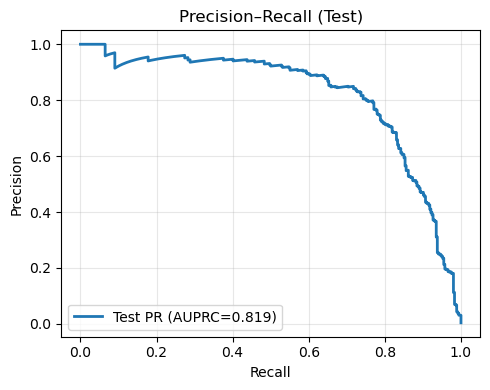

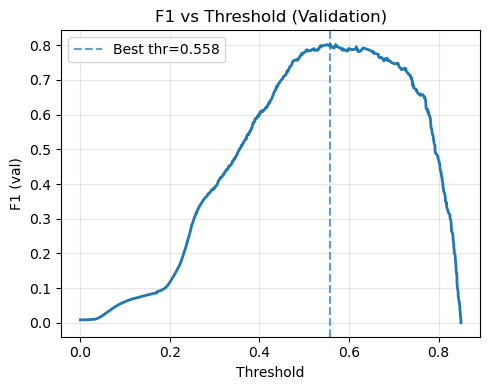

In [35]:
''' this was with aplha 0.85 and gamma = 2.5 '''

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, precision_recall_curve, average_precision_score

@torch.no_grad()
def collect_probs(model, data_loader, device, target_mode="last"):
    model.eval()
    probs_all, labels_all = [], []
    for x, y, m in data_loader:
        x, y, m = x.to(device), y.to(device), m.to(device)
        logits = model(x)                    # (B, T)
        probs  = torch.sigmoid(logits)       # (B, T)
        tm = make_target_mask(m, mode=target_mode)  # (B, T) one-hot per window
        # pick the supervised timestep
        probs_t = probs[tm.bool()]           # (B,)
        labels_t = y[tm.bool()]              # (B,)
        probs_all.append(probs_t.detach().cpu())
        labels_all.append(labels_t.detach().cpu())
    y_true = torch.cat(labels_all).numpy().astype(int)
    y_prob = torch.cat(probs_all).numpy()
    return y_true, y_prob

import numpy as np
import matplotlib.pyplot as plt

def pick_threshold_by_f1(y_true, y_prob):
    P, R, th = precision_recall_curve(y_true, y_prob)
    # precision_recall_curve returns len(th)+1 points; align F1 to P,R
    f1 = 2 * P * R / (P + R + 1e-8)
    # the first P,R correspond to threshold = +inf (no positives); skip that for argmax
    best_idx = np.nanargmax(f1[1:]) + 1
    best_thr = th[best_idx - 1] if len(th) else 0.5
    return float(best_thr), float(f1[best_idx]), float(P[best_idx]), float(R[best_idx]), (P, R, th, f1)

'''def pick_threshold_by_f1(y_true, y_prob):
    # Guard degenerate cases
    if len(np.unique(y_true)) < 2:
        # Can't build a PR curve if only one class present
        # Fall back to a default threshold and report F1 at that threshold
        default_thr = 0.4
        return default_thr, f1_score(y_true, (y_prob >= default_thr).astype(int), zero_division=0), np.nan, np.nan, (None, None, None, None)

    P, R, th = precision_recall_curve(y_true, y_prob)   # len(P)=len(R)=len(th)+1
    f1 = 2 * P * R / (P + R + 1e-8)
    f1 = np.nan_to_num(f1, nan=0.0)

    # Skip the first point (threshold = +inf), then pick best F1
    candidates = f1[1:]
    if candidates.size == 0:
        # Very small/degenerate case
        best_thr = 0.5
        return best_thr, f1_score(y_true, (y_prob >= best_thr).astype(int), zero_division=0), np.nan, np.nan, (P, R, th, f1)

    best_val = candidates.max()
    # Among ties, choose the smallest threshold (=> higher recall)
    tie_idx = np.where(candidates == best_val)[0]
    best_idx = tie_idx.min() + 1  # +1 due to skipping the first point

    best_thr = th[best_idx - 1] if len(th) else 0.5
    return float(best_thr), float(f1[best_idx]), float(P[best_idx]), float(R[best_idx]), (P, R, th, f1)'''


def eval_at_threshold(y_true, y_prob, thr):
    y_pred = (y_prob >= thr).astype(int)
    return dict(
        precision=precision_score(y_true, y_pred, zero_division=0),
        recall=recall_score(y_true, y_pred, zero_division=0),
        f1=f1_score(y_true, y_pred, zero_division=0),
        cm=confusion_matrix(y_true, y_pred)
    )

# --- collect probs ---
y_true_val, y_prob_val = collect_probs(model, val_loader, device, target_mode="last")
y_true_test, y_prob_test = collect_probs(model, test_loader, device, target_mode="last")

# --- pick threshold on VAL by max F1 ---
best_thr, best_f1, best_P, best_R, (P, R, th, f1_curve) = pick_threshold_by_f1(y_true_val, y_prob_val)
ap_val = average_precision_score(y_true_val, y_prob_val)
print(f"[VAL] Best threshold={best_thr:.3f} | F1={best_f1:.3f} (P={best_P:.3f}, R={best_R:.3f}) | AUPRC={ap_val:.3f}")

# --- evaluate TEST at that threshold ---
test_metrics = eval_at_threshold(y_true_test, y_prob_test, best_thr)
ap_test = average_precision_score(y_true_test, y_prob_test)

print(f"[TEST] thr={best_thr:.3f} | "
      f"P={test_metrics['precision']:.3f} R={test_metrics['recall']:.3f} "
      f"F1={test_metrics['f1']:.3f} | AUPRC={ap_test:.3f}")
print("Confusion matrix (TEST):")
print(test_metrics["cm"])

# === Classification report (FIX) ===
y_pred_test = (y_prob_test >= best_thr).astype(int)  # <-- define predictions
acc = accuracy_score(y_true_test, y_pred_test)
print(f"Accuracy (TEST): {acc:.3f}")

print("Classification Report (TEST):")
print(classification_report(
    y_true_test,
    y_pred_test,
    target_names=["Undisturbed (0)", "Disturbed (1)"],
    zero_division=0,
    digits=3
))

# --- plots (optional; comment out if plotting is unstable) ---
# (a) Precision–Recall curve (use PROBABILITIES)
plt.figure(figsize=(5,4))
P_test, R_test, _ = precision_recall_curve(y_true_test, y_prob_test)
plt.plot(R_test, P_test, lw=2, label=f"Test PR (AUPRC={ap_test:.3f})")
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Precision–Recall (Test)")
plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()

# (b) F1 vs threshold (from VAL)
plt.figure(figsize=(5,4))
f1_vs_th = 2 * P[1:] * R[1:] / (P[1:] + R[1:] + 1e-8)  # align with thresholds
plt.plot(th, f1_vs_th, lw=2)
plt.axvline(best_thr, ls="--", alpha=0.7, label=f"Best thr={best_thr:.3f}")
plt.xlabel("Threshold"); plt.ylabel("F1 (val)"); plt.title("F1 vs Threshold (Validation)")
plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()

# Save model weights
torch.save(model.state_dict(), "/home/eoem/Desktop/ai4forest/AI_inference/models_unet/1dunet_w5_last_bands_indices_v5.pth") 

In [56]:
### option 2 for training and select best epoch - test it or delet:

import numpy as np
import torch
from sklearn.metrics import f1_score, precision_recall_curve, average_precision_score, \
                            accuracy_score, precision_score, recall_score, confusion_matrix

def train_and_select_best(model, train_loader, val_loader, device, loss_fn, optimizer,
                          num_epochs=30, target_mode="last",
                          select_by="auprc",           # or "loss"
                          ckpt_path="best_model.pt",
                          grad_clip=1.0):
    """
    Trains, logs curves, and saves the *best epoch* snapshot by val AUPRC (default) or lowest val loss.
    Returns: history dict, and a dict with best_epoch/metric info.
    """
    history = {"train_loss": [], "val_loss": [], "train_f1": [], "val_f1": [], "val_auprc": []}
    best_metric = -np.inf if select_by == "auprc" else np.inf
    best_epoch = -1

    for epoch in range(num_epochs):
        # -------- TRAIN --------
        model.train()
        train_loss, train_f1 = 0.0, 0.0
        for x, y, m in train_loader:
            x, y, m = x.to(device), y.to(device), m.to(device)
            optimizer.zero_grad()

            y_hat = model(x)                    # (B, T)
            per_elem = loss_fn(y_hat, y)        # (B, T)
            tm = make_target_mask(m, mode=target_mode)
            loss = (per_elem * tm).sum() / (tm.sum() + 1e-8)

            loss.backward()
            if grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()

            preds = (torch.sigmoid(y_hat) > 0.5).float()
            train_f1 += f1_score(y[tm.bool()].cpu(), preds[tm.bool()].cpu(), zero_division=0)
            train_loss += loss.item()

        train_loss /= max(1, len(train_loader))
        train_f1   /= max(1, len(train_loader))

        # -------- VALIDATION --------
        model.eval()
        val_loss = 0.0
        val_probs_all, val_labels_all = [], []
        with torch.no_grad():
            for x, y, m in val_loader:
                x, y, m = x.to(device), y.to(device), m.to(device)
                y_hat = model(x)
                per_elem = loss_fn(y_hat, y)
                tm = make_target_mask(m, mode=target_mode)
                loss = (per_elem * tm).sum() / (tm.sum() + 1e-8)
                val_loss += loss.item()

                probs = torch.sigmoid(y_hat)
                val_probs_all.append(probs[tm.bool()].detach().cpu())
                val_labels_all.append(y[tm.bool()].detach().cpu())

        val_loss /= max(1, len(val_loader))
        y_true_va = torch.cat(val_labels_all).numpy().astype(int) if val_labels_all else np.array([])
        y_prob_va = torch.cat(val_probs_all).numpy() if val_probs_all else np.array([])

        if y_true_va.size and len(np.unique(y_true_va)) == 2:
            ap_va = average_precision_score(y_true_va, y_prob_va)
            P, R, th = precision_recall_curve(y_true_va, y_prob_va)
            f1_curve = 2 * P * R / (P + R + 1e-8)
            f1_va_best = float(np.nanmax(f1_curve[1:])) if f1_curve.size > 1 else 0.0
        else:
            ap_va = np.nan
            f1_va_best = 0.0

        # log
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_f1"].append(train_f1)
        history["val_f1"].append(f1_va_best)         # best-per-epoch (monitoring only)
        history["val_auprc"].append(float(ap_va) if ap_va == ap_va else np.nan)

        print(f"Epoch {epoch+1:02d} | "
              f"TrainLoss {train_loss:.4f} | ValLoss {val_loss:.4f} | "
              f"TrainF1 {train_f1:.4f} | ValF1* {f1_va_best:.4f} | ValAUPRC {ap_va:.4f}")

        # select best epoch
        current_metric = ap_va if select_by == "auprc" else -val_loss
        is_better = (select_by == "auprc" and (ap_va == ap_va) and current_metric > best_metric) or \
                    (select_by == "loss"  and current_metric > best_metric)
        if is_better:
            best_metric = current_metric
            best_epoch = epoch + 1
            torch.save({
                "epoch": best_epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_loss": val_loss,
                "val_auprc": ap_va
            }, ckpt_path)

    return history, {"best_epoch": best_epoch, "best_metric": best_metric,
                     "ckpt_path": ckpt_path, "select_by": select_by}

''' run training'''
# model = safe_to_device(AlbasUNet(in_channels=nF), device)   # ← old
### OPTION 1
# model = safe_to_device(SmallUNet1D(in_channels=nF, base=16, p_drop=0.2), device)  # ← new

### OPTION 2
# pick norm based on batch size:
#   small batches (<16): norm='ln' (via GN(1,C)) or norm='gn8'
#   larger batches: norm='bn' is fine
model = safe_to_device(SmallUNet1D(in_channels=nF, base=16, p_drop=0.2,
                    norm='ln', kernel_sizes_small=(1,3,5), tdrop_rate=0.2), device) 

# --- Optimizer: choose ONE ---
# A) AdamW (good default with weight decay decoupled)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,            # AdamW usually needs a slightly lower LR
    weight_decay=1e-2,  # try 1e-2 → 1e-4 depending on overfitting
    betas=(0.9, 0.999),
    eps=1e-8,
)
# B) OR Adam + small weight_decay (comment AdamW above if you use this)
# optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

loss_fn = FocalLoss(alpha=0.85, gamma=3, reduction='none')

TARGET_MODE = "last"        # or "last" or "second_last" or "idx:<k>"
train_and_select_best(model, train_loader, val_loader, device, loss_fn, optimizer, num_epochs=30, target_mode=TARGET_MODE)

Epoch 01 | TrainLoss 0.0015 | ValLoss 0.0004 | TrainF1 0.0957 | ValF1* 0.7633 | ValAUPRC 0.8132
Epoch 02 | TrainLoss 0.0010 | ValLoss 0.0004 | TrainF1 0.1420 | ValF1* 0.7598 | ValAUPRC 0.8285
Epoch 03 | TrainLoss 0.0010 | ValLoss 0.0007 | TrainF1 0.1425 | ValF1* 0.7959 | ValAUPRC 0.8465
Epoch 04 | TrainLoss 0.0010 | ValLoss 0.0004 | TrainF1 0.1428 | ValF1* 0.7938 | ValAUPRC 0.8372
Epoch 05 | TrainLoss 0.0009 | ValLoss 0.0004 | TrainF1 0.1515 | ValF1* 0.7966 | ValAUPRC 0.8476
Epoch 06 | TrainLoss 0.0009 | ValLoss 0.0004 | TrainF1 0.1477 | ValF1* 0.8000 | ValAUPRC 0.8395
Epoch 07 | TrainLoss 0.0010 | ValLoss 0.0004 | TrainF1 0.1473 | ValF1* 0.8000 | ValAUPRC 0.8394
Epoch 08 | TrainLoss 0.0009 | ValLoss 0.0004 | TrainF1 0.1503 | ValF1* 0.7890 | ValAUPRC 0.8435
Epoch 09 | TrainLoss 0.0009 | ValLoss 0.0004 | TrainF1 0.1481 | ValF1* 0.7933 | ValAUPRC 0.8481
Epoch 10 | TrainLoss 0.0009 | ValLoss 0.0004 | TrainF1 0.1501 | ValF1* 0.8020 | ValAUPRC 0.8512
Epoch 11 | TrainLoss 0.0009 | ValLoss 0.

({'train_loss': [0.0014689097364338206,
   0.00101865447011088,
   0.0009939135940610778,
   0.0010223442507522574,
   0.000941699988207717,
   0.0009297727261616052,
   0.0009587659385371039,
   0.0009149800337098929,
   0.0009355577576574428,
   0.0009076495302435997,
   0.0009280490276167138,
   0.0008829785491828407,
   0.0009249438733672206,
   0.0008930918718232622,
   0.0009071514722492151,
   0.0008980882706509692,
   0.0009153957641137894,
   0.0008776888102564634,
   0.0009075519016943256,
   0.000901868507033714,
   0.0008761425720481676,
   0.000879097930668587,
   0.0008592777770696074,
   0.0008840628653515825,
   0.0008882240136113591,
   0.0008657780159734441,
   0.0008732217685543372,
   0.000829753280360519,
   0.0008417469642436143,
   0.0008752109883813508],
  'val_loss': [0.0004367031175954178,
   0.0004318866400599789,
   0.0006968914971964782,
   0.0004254070019607304,
   0.00039981560891689,
   0.0004150110822094625,
   0.000381642210854433,
   0.000392214852223

In [57]:
### option 2 for evalutation

@torch.no_grad()
def final_eval_with_val_threshold(model, device, ckpt_path, val_loader, test_loader, target_mode="last"):
    ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    model.to(device)
    model.eval()
    print(f"Loaded best model from epoch {ckpt['epoch']}.")

    # 1) Calibrate threshold ONCE on validation
    y_true_val, y_prob_val = collect_probs(model, val_loader, device, target_mode=target_mode)
    best_thr, best_f1_val, best_P_val, best_R_val, _ = pick_threshold_by_f1(y_true_val, y_prob_val)
    ap_val = average_precision_score(y_true_val, y_prob_val) if len(np.unique(y_true_val))==2 else np.nan
    print(f"[VAL] thr*={best_thr:.3f} | F1*={best_f1_val:.3f} | AUPRC={ap_val:.3f}")

    # 2) Apply frozen threshold to TEST (once)
    y_true_test, y_prob_test = collect_probs(model, test_loader, device, target_mode=target_mode)
    y_pred_test = (y_prob_test >= best_thr).astype(int)
    test_metrics = {
        "precision": precision_score(y_true_test, y_pred_test, zero_division=0),
        "recall":    recall_score(y_true_test, y_pred_test, zero_division=0),
        "f1":        f1_score(y_true_test, y_pred_test, zero_division=0),
        "accuracy":  accuracy_score(y_true_test, y_pred_test),
        "cm":        confusion_matrix(y_true_test, y_pred_test, labels=[0,1]),
        "auprc":     average_precision_score(y_true_test, y_prob_test) if len(np.unique(y_true_test))==2 else np.nan
    }
    print(f"[TEST] thr={best_thr:.3f} | "
          f"P={test_metrics['precision']:.3f} R={test_metrics['recall']:.3f} "
          f"F1={test_metrics['f1']:.3f} Acc={test_metrics['accuracy']:.3f} | "
          f"AUPRC={test_metrics['auprc']:.3f}")
    print("Confusion matrix (TEST) [rows=true 0/1, cols=pred 0/1]:\n", test_metrics["cm"])
    return best_thr, test_metrics


def plot_history(history, title_suffix=""):
    ep = np.arange(1, len(history["train_loss"]) + 1)
    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.plot(ep, history["train_loss"], marker="o", label="Train Loss")
    plt.plot(ep, history["val_loss"],   marker="o", label="Val Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title(f"Loss over epochs{title_suffix}")
    plt.grid(True, alpha=0.3); plt.legend()

    plt.subplot(1,2,2)
    plt.plot(ep, history["train_f1"], marker="o", label="Train F1")
    plt.plot(ep, history["val_f1"],   marker="o", label="Val F1 (best-per-epoch)")
    plt.xlabel("Epoch"); plt.ylabel("F1"); plt.title(f"F1 over epochs{title_suffix}")
    plt.grid(True, alpha=0.3); plt.legend()

    plt.tight_layout(); plt.show()


Epoch 01 | TrainLoss 0.0009 | ValLoss 0.0004 | TrainF1 0.1545 | ValF1* 0.8189 | ValAUPRC 0.8607
Epoch 02 | TrainLoss 0.0009 | ValLoss 0.0004 | TrainF1 0.1537 | ValF1* 0.8278 | ValAUPRC 0.8636
Epoch 03 | TrainLoss 0.0009 | ValLoss 0.0004 | TrainF1 0.1508 | ValF1* 0.8135 | ValAUPRC 0.8646
Epoch 04 | TrainLoss 0.0008 | ValLoss 0.0004 | TrainF1 0.1573 | ValF1* 0.8179 | ValAUPRC 0.8698
Epoch 05 | TrainLoss 0.0008 | ValLoss 0.0004 | TrainF1 0.1578 | ValF1* 0.8355 | ValAUPRC 0.8615
Epoch 06 | TrainLoss 0.0009 | ValLoss 0.0004 | TrainF1 0.1517 | ValF1* 0.8189 | ValAUPRC 0.8602
Epoch 07 | TrainLoss 0.0009 | ValLoss 0.0005 | TrainF1 0.1524 | ValF1* 0.8368 | ValAUPRC 0.8627
Epoch 08 | TrainLoss 0.0009 | ValLoss 0.0004 | TrainF1 0.1561 | ValF1* 0.8111 | ValAUPRC 0.8564
Epoch 09 | TrainLoss 0.0009 | ValLoss 0.0004 | TrainF1 0.1513 | ValF1* 0.8251 | ValAUPRC 0.8558
Epoch 10 | TrainLoss 0.0009 | ValLoss 0.0004 | TrainF1 0.1523 | ValF1* 0.8152 | ValAUPRC 0.8629
Epoch 11 | TrainLoss 0.0009 | ValLoss 0.

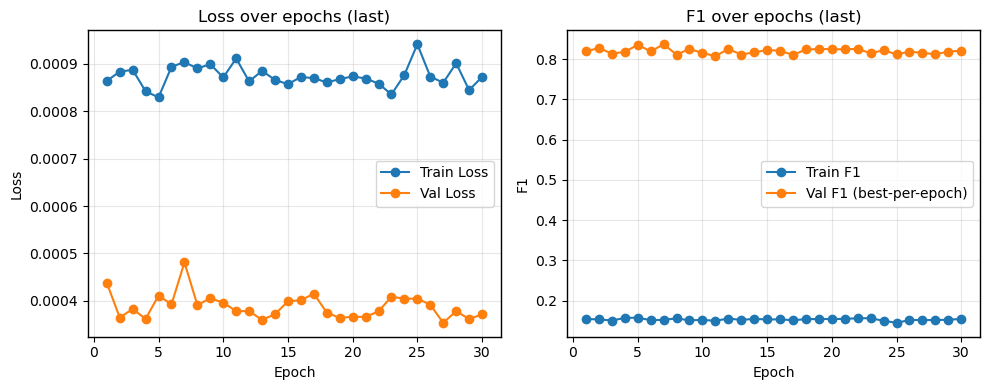

Loaded best model from epoch 4.


/tmp/ipykernel_52123/1525558565.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location=device)


[VAL] thr*=0.642 | F1*=0.818 | AUPRC=0.870
[TEST] thr=0.642 | P=0.841 R=0.718 F1=0.774 Acc=0.998 | AUPRC=0.827
Confusion matrix (TEST) [rows=true 0/1, cols=pred 0/1]:
 [[89827    48]
 [  100   254]]


In [58]:
# instantiate model/optimizer/loss as you already do
# model = safe_to_device(SmallUNet1D(...), device)
# optimizer = torch.optim.AdamW(...)
# loss_fn = FocalLoss(alpha=0.85, gamma=2, reduction='none')

TARGET_MODE = "last"  # keep consistent across train/val/test

history, best_info = train_and_select_best(
    model, train_loader, val_loader, device,
    loss_fn, optimizer,
    num_epochs=30,
    target_mode=TARGET_MODE,
    select_by="auprc",            # or "loss"
    ckpt_path="best_model.pt"
)

plot_history(history, title_suffix=f" ({TARGET_MODE})")

best_thr, test_metrics = final_eval_with_val_threshold(
    model, device, best_info["ckpt_path"],
    val_loader, test_loader,
    target_mode=TARGET_MODE
)


In [ ]:
import numpy as np
import torch
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

def evaluate_model_masked(model, data_loader, device, loss_fn, target_mode="last", threshold_range=[0.4, 0.45, 0.48, 0.5]):
    model.eval()
    all_probs, all_labels = [], []
    total_loss = 0.0

    with torch.no_grad():
        for x, y, m in data_loader:
            x, y, m = x.to(device), y.to(device), m.to(device)

            # Mask out padded timesteps before feeding to the model
            x = x * m.unsqueeze(1)

            y_hat = model(x)                     # (B, T)
            per_elem = loss_fn(y_hat, y)         # (B, T)
            tm = make_target_mask(m, mode=target_mode)  # (B, T) -> 1 at supervised timestep
            loss = (per_elem * tm).sum() / tm.sum().clamp_min(1)
            total_loss += loss.item()

            # Collect only valid target timesteps for metric calculation
            probs = torch.sigmoid(y_hat)[tm.bool()].cpu().numpy()
            labels = y[tm.bool()].cpu().numpy()
            all_probs.extend(probs.tolist())
            all_labels.extend(labels.tolist())

    avg_loss = total_loss / len(data_loader)
    y_true = np.array(all_labels)
    y_prob = np.array(all_probs)

    best_results = {"f1": -1}
    for thresh in threshold_range:
        y_pred = (y_prob > thresh).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        acc = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, zero_division=0)
        rec = recall_score(y_true, y_pred, zero_division=0)

        if f1 > best_results["f1"]:
            best_results = {
                "thresh": thresh,
                "f1": f1,
                "acc": acc,
                "prec": prec,
                "rec": rec
            }

    print(
        f"[TEST] Best threshold {best_results['thresh']:.2f} | "
        f"F1 {best_results['f1']:.4f} | Acc {best_results['acc']:.4f} | "
        f"Prec {best_results['prec']:.4f} | Rec {best_results['rec']:.4f}"
    )

    return y_true, (y_prob > best_results["thresh"]).astype(int), avg_loss, best_results

# assume you already have: model, test_loader, device, loss_fn
y_true, y_pred, test_loss, test_results = evaluate_model_masked(
    model,
    test_loader,
    device,
    loss_fn=bce_logits,  # or FocalLoss()
    target_mode="last",
    threshold_range=[0.4, 0.45, 0.48, 0.5],
)

print(f"Final test F1: {test_results['f1']:.4f} at threshold {test_results['thresh']:.2f}")


In [ ]:
import matplotlib.pyplot as plt

epochs = list(range(1, len(train_losses) + 1))

plt.figure(figsize=(12, 8))

# Loss
plt.subplot(2, 2, 1)
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(2, 2, 2)
plt.plot(epochs, train_accs, label='Train Acc')
plt.plot(epochs, val_accs, label='Val Acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# F1 Score
plt.subplot(2, 2, 3)
plt.plot(epochs, train_f1s, label='Train F1')
plt.plot(epochs, val_f1s, label='Val F1')
plt.title('F1 Score')
plt.xlabel('Epoch')
plt.ylabel('F1')
plt.legend()

# Precision, Recall, Threshold
plt.subplot(2, 2, 4)
plt.plot(epochs, val_precisions, label='Val Precision')
plt.plot(epochs, val_recalls, label='Val Recall')
plt.plot(epochs, val_thresholds, label='Best Threshold')
plt.title('Precision, Recall & Threshold')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
#compute average f1 score for each step

# Subplot 2: F1 evolution over training
plt.subplot(2, 2, 2)
epochs = range(1, len(train_f1s) + 1)
plt.plot(epochs, train_f1s, label='Train F1', marker='o')
plt.plot(epochs, val_f1s, label='Val F1', marker='s')
plt.title('F1 Score Evolution')
plt.xlabel('Epoch')
plt.ylabel('F1 Score')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 3: Position F1 evolution over epochs (optional - shows how positions change)
plt.subplot(2, 2, 3)
val_position_f1s_array = np.array(val_position_f1s)  # Shape: (epochs, positions)
for pos in range(8):
    plt.plot(epochs, val_position_f1s_array[:, pos], label=f'Year {pos+1}', alpha=0.7)
plt.title('Position F1 Evolution Over Training')
plt.xlabel('Epoch')
plt.ylabel('F1 Score')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)

# Subplot 4: Summary statistics
plt.subplot(2, 2, 4)
avg_f1 = np.mean(best_position_f1s)
std_f1 = np.std(best_position_f1s)
plt.text(0.1, 0.8, f'Best Overall F1: {best_val_f1:.4f}', fontsize=12, transform=plt.gca().transAxes)
plt.text(0.1, 0.7, f'Best Position: Year {best_position_idx+1}', fontsize=12, transform=plt.gca().transAxes)
plt.text(0.1, 0.6, f'Best Position F1: {best_position_f1s[best_position_idx]:.4f}', fontsize=12, transform=plt.gca().transAxes)
plt.text(0.1, 0.5, f'Average Position F1: {avg_f1:.4f}', fontsize=12, transform=plt.gca().transAxes)
plt.text(0.1, 0.4, f'Position F1 Std: {std_f1:.4f}', fontsize=12, transform=plt.gca().transAxes)
plt.title('Summary Statistics')
plt.axis('off')

plt.tight_layout()
plt.show()